Mean: 229.86
Median: 54.49
Skewness: 12.9708


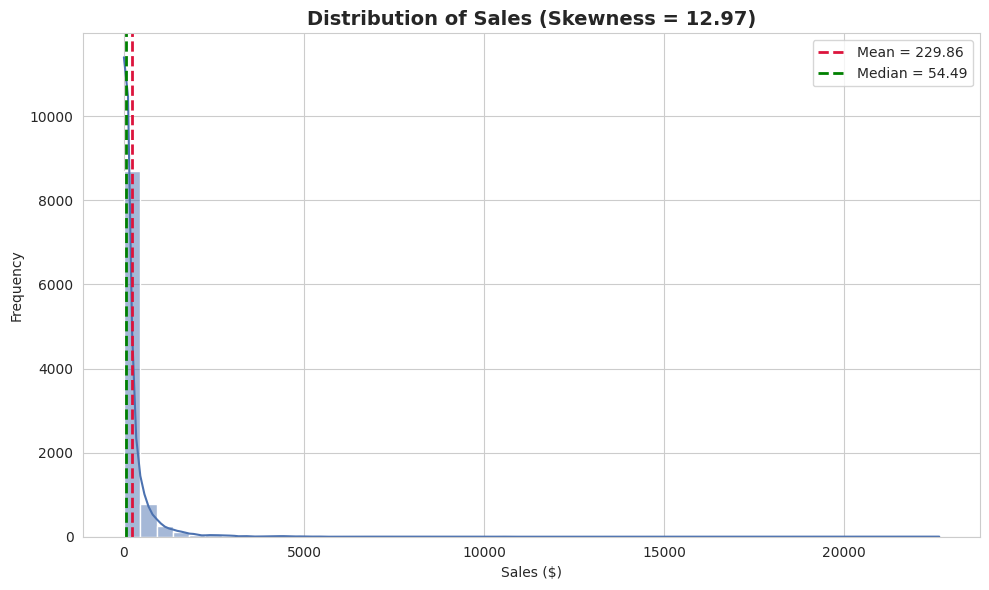

In [3]:
#task 1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
sales = df['Sales']

mean_sales = sales.mean()
median_sales = sales.median()
skewness = skew(sales)

print(f"Mean: {mean_sales:.2f}")
print(f"Median: {median_sales:.2f}")
print(f"Skewness: {skewness:.4f}")

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(sales, kde=True, bins=50, color="#4C72B0", edgecolor="white", ax=ax)
ax.axvline(mean_sales, color="crimson", linestyle="--", linewidth=2, label=f"Mean = {mean_sales:.2f}")
ax.axvline(median_sales, color="green", linestyle="--", linewidth=2, label=f"Median = {median_sales:.2f}")
ax.set_title(f"Distribution of Sales (Skewness = {skewness:.2f})", fontsize=14, fontweight="bold")
ax.set_xlabel("Sales ($)")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

Results: Mean = 229.86, Median = 54.49, Skewness = 12.97

The distribution is strongly right-skewed (mean >> median, skewness far above 0), so a few large orders pull the mean up, the median is the more reliable here.

/tmp/ipykernel_6866/4023078298.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Category', y='Profit', ax=axes[0], palette='Set2', inner='quartile')
/tmp/ipykernel_6866/4023078298.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x='Category', y='Profit', ax=axes[1], palette='Set2',


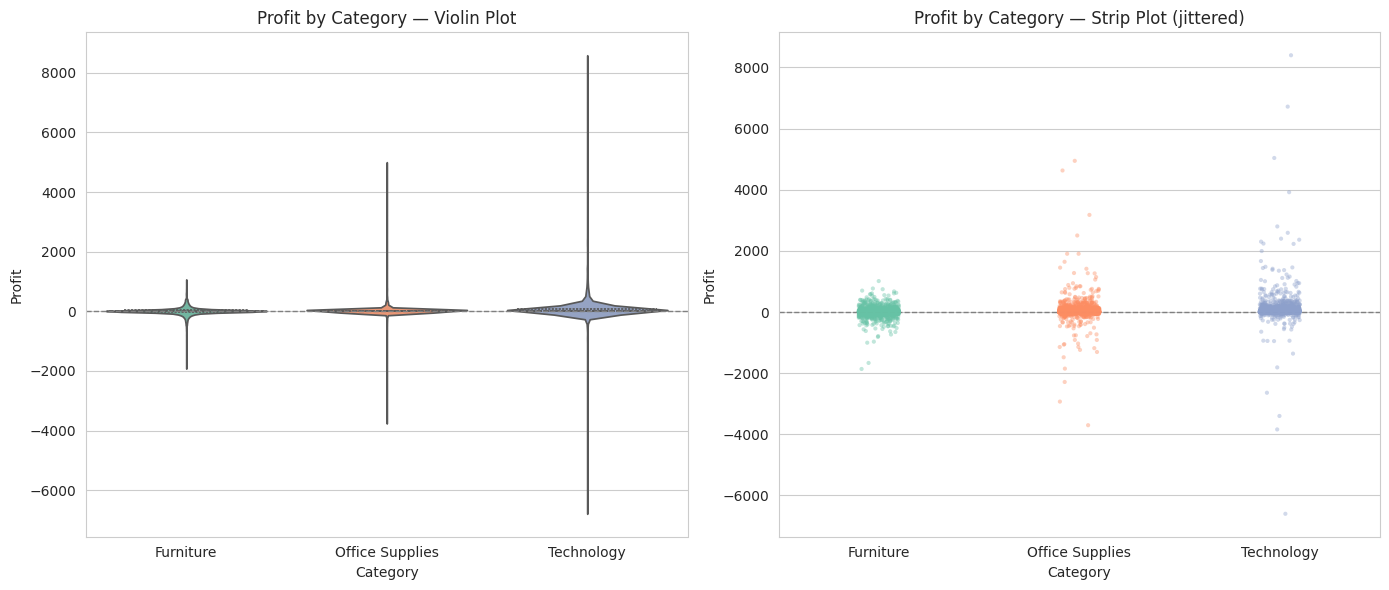

In [16]:
#Task2
#Violin + strip plot: Profit by Category
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(data=df, x='Category', y='Profit', ax=axes[0], palette='Set2', inner='quartile')
axes[0].set_title('Profit by Category — Violin Plot')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)

sns.stripplot(data=df, x='Category', y='Profit', ax=axes[1], palette='Set2',
              jitter=True, alpha=0.4, size=3)
axes[1].set_title('Profit by Category — Strip Plot (jittered)')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()



Violin vs strip: Violin wins ,Technology's violin is visibly wider and multi-lobed (profit spans -$6,600 to +$8,400), which the overlapping strip points obscure.

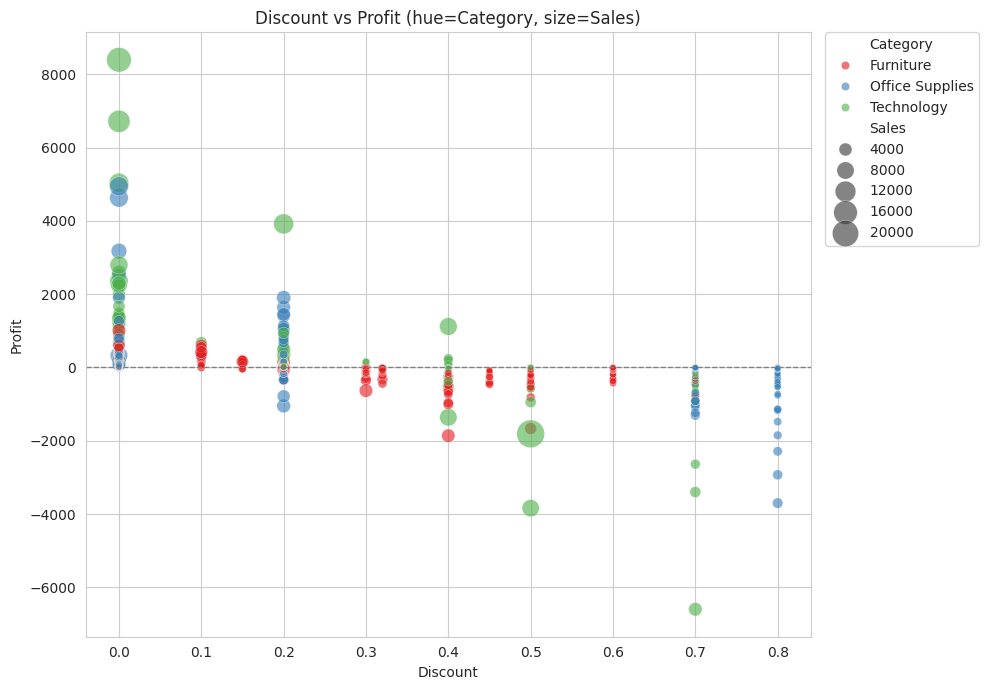

In [17]:
#Task3
#Multivariate scatter: Discount vs Profit
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', size='Sales',
                 sizes=(20, 400), alpha=0.6, palette='Set1')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Discount vs Profit (hue=Category, size=Sales)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

3. Multivariate scatter: At discount = 0.5, a large bubble (high Sales, Technology) sits deep in negative profit, big discounted Tech orders drive the worst losses, visible only via size+hue together.

Pearson:
           Sales  Quantity  Discount  Profit
Sales     1.000     0.201    -0.028   0.479
Quantity  0.201     1.000     0.009   0.066
Discount -0.028     0.009     1.000  -0.219
Profit    0.479     0.066    -0.219   1.000

Spearman:
           Sales  Quantity  Discount  Profit
Sales     1.000     0.327    -0.057   0.518
Quantity  0.327     1.000    -0.001   0.234
Discount -0.057    -0.001     1.000  -0.543
Profit    0.518     0.234    -0.543   1.000

Absolute difference:
           Sales  Quantity  Discount  Profit
Sales     0.000     0.127     0.029   0.039
Quantity  0.127     0.000     0.010   0.168
Discount  0.029     0.010     0.000   0.324
Profit    0.039     0.168     0.324   0.000


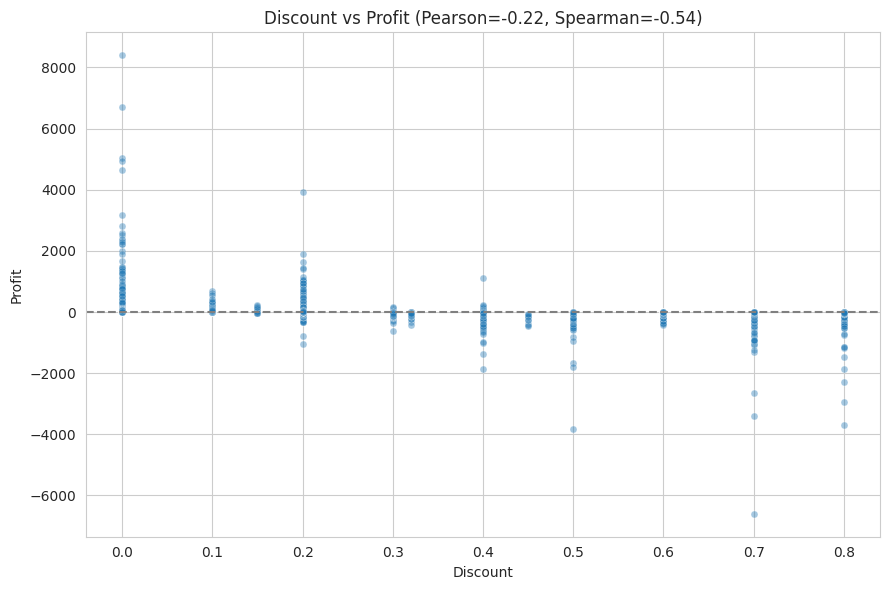

In [9]:
#Task4
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

pearson = df[num_cols].corr(method='pearson')
spearman = df[num_cols].corr(method='spearman')

print("Pearson:\n", pearson.round(3))
print("\nSpearman:\n", spearman.round(3))
print("\nAbsolute difference:\n", (pearson - spearman).abs().round(3))

# Discount vs Profit disagrees most: Pearson -0.22 vs Spearman -0.54
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.4, s=25)
plt.axhline(0, color='gray', linestyle='--')
plt.title(f"Discount vs Profit (Pearson={pearson.loc['Discount','Profit']:.2f}, "
          f"Spearman={spearman.loc['Discount','Profit']:.2f})")
plt.tight_layout()
plt.show()

Caveat: this correlation (in either form) shows association only, it doesn't prove discounting causes profit loss; both could be driven by a confounder (e.g., discounts being applied more often to already low-margin product lines).

Category  Furniture  Office Supplies  Technology      Total
Region                                                     
Central    163797.0         167026.0    170416.0   501240.0
East       208291.0         205516.0    264974.0   678781.0
South      117299.0         125651.0    148772.0   391722.0
West       252613.0         220853.0    251992.0   725458.0
Total      742000.0         719047.0    836154.0  2297201.0


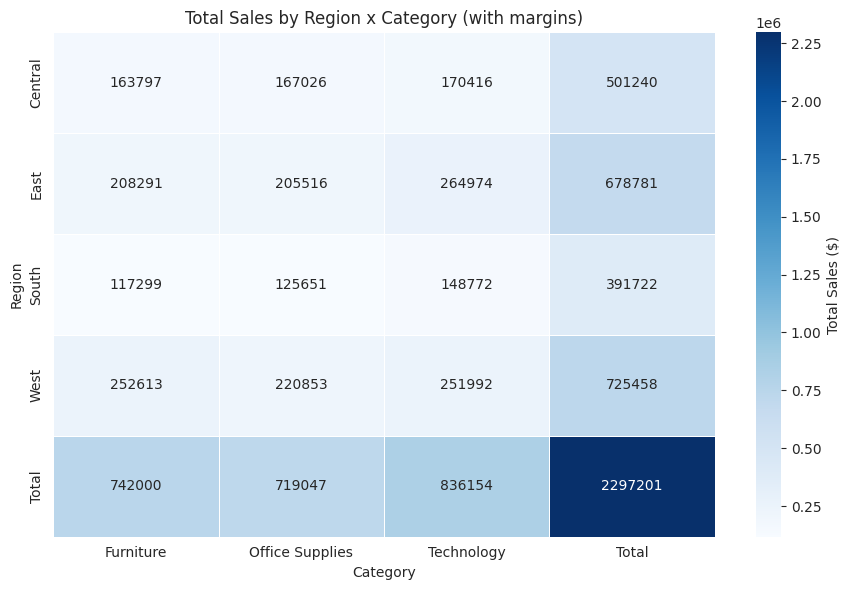

In [11]:
#Task5
pivot = pd.pivot_table(df, values='Sales', index='Region', columns='Category',
                        aggfunc='sum', margins=True, margins_name='Total')
print(pivot.round(0))

plt.figure(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues',
            cbar_kws={'label': 'Total Sales ($)'}, linewidths=0.5, linecolor='white')
plt.title('Total Sales by Region x Category (with margins)')
plt.tight_layout()
plt.show()
#East–Technology ($264,974) brings in the most revenue of any single region-category pair.
# But overall, West is the top region ($725,458), since its sales are spread fairly evenly across Furniture, Office Supplies,
#and Technology instead of relying on one strong category.


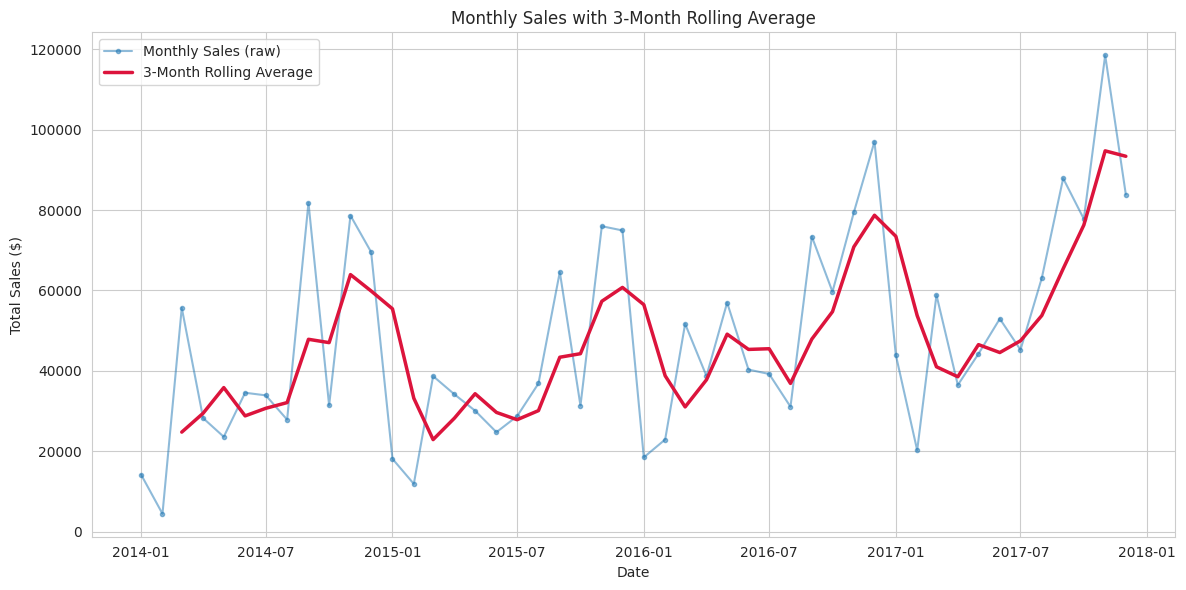

In [12]:
#task6
df['Order Date'] = pd.to_datetime(df['Order Date'])

monthly = df.set_index('Order Date')['Sales'].resample('MS').sum()
rolling = monthly.rolling(window=3).mean()

plt.figure(figsize=(12, 6))
plt.plot(monthly.index, monthly.values, marker='o', markersize=3, alpha=0.5, label='Monthly Sales (raw)')
plt.plot(rolling.index, rolling.values, color='crimson', linewidth=2.5, label='3-Month Rolling Average')
plt.title('Monthly Sales with 3-Month Rolling Average')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.legend()
plt.tight_layout()
plt.show()

The rolling average smooths out month-to-month noise, revealing a steady upward trend and a recurring year-end sales peak. The raw line is too jagged to show this clearly.

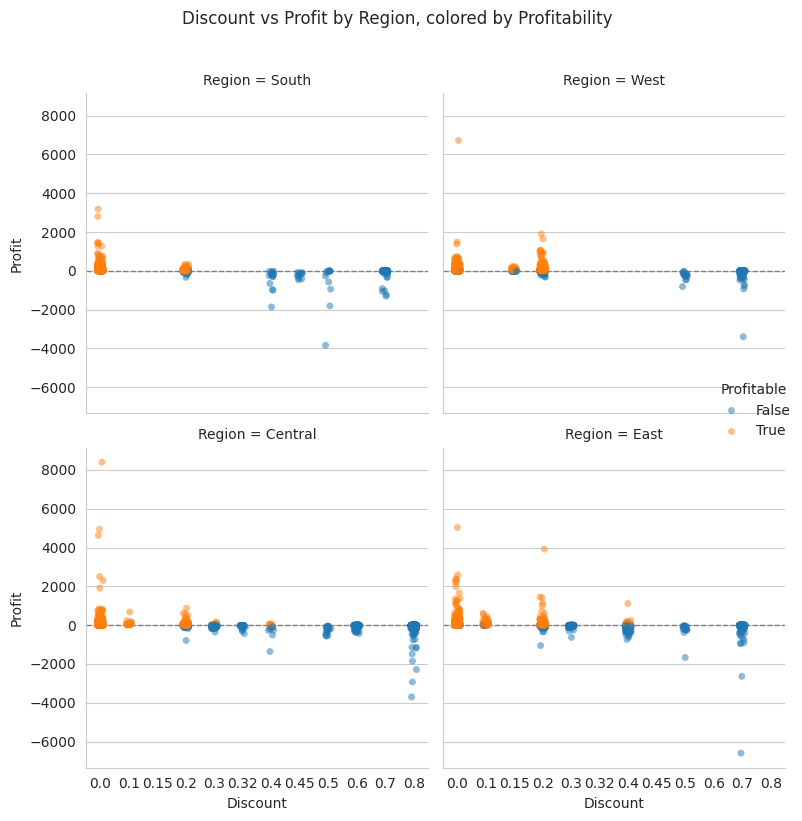

In [18]:
#task7
df['Profitable'] = df['Profit'] > 0

g = sns.catplot(data=df, x='Discount', y='Profit', col='Region', hue='Profitable',
                 kind='strip', jitter=True, alpha=0.5, height=4, aspect=0.9, col_wrap=2)
g.map(plt.axhline, y=0, color='gray', linestyle='--', linewidth=1)
g.fig.suptitle('Discount vs Profit by Region, colored by Profitability', y=1.02)
plt.tight_layout()
plt.show()

Central stands out, it still has profitable orders (orange) at discounts up to 0.4–0.5, while South and West turn almost entirely unprofitable (blue) as soon as discount passes 0.2.

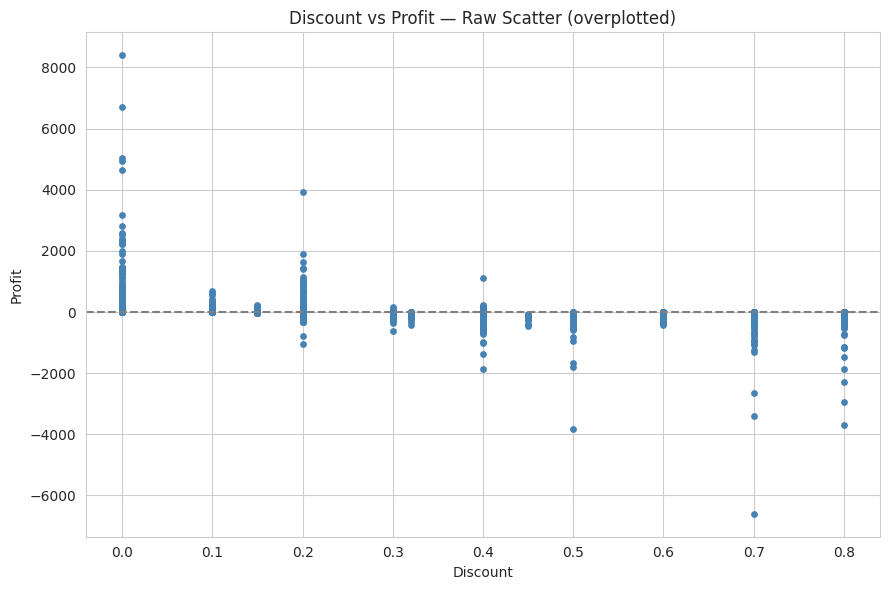

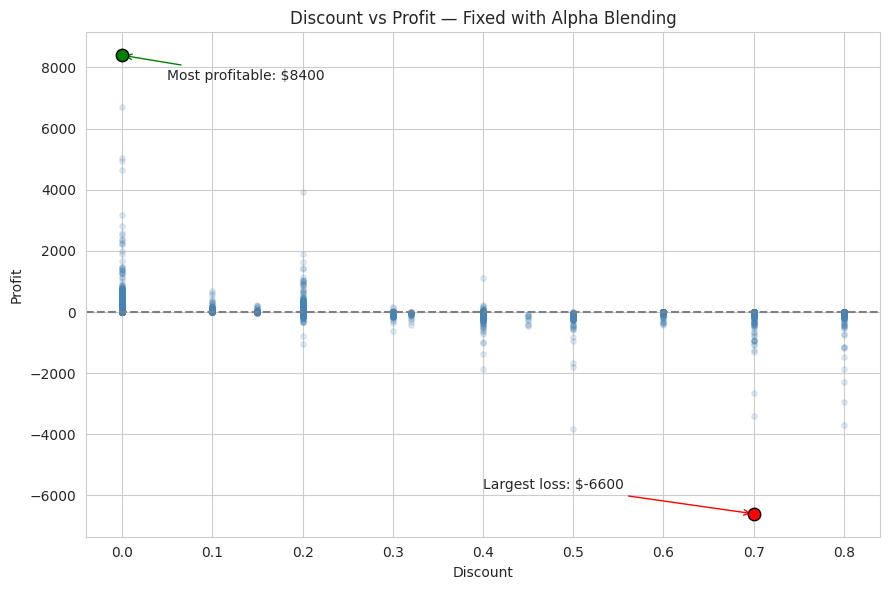

In [20]:
#Task8
max_profit_row = df.loc[df['Profit'].idxmax()]
max_loss_row = df.loc[df['Profit'].idxmin()]

# Raw scatter (heavy overplotting)
plt.figure(figsize=(9, 6))
plt.scatter(df['Discount'], df['Profit'], s=15, color='steelblue')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Discount vs Profit — Raw Scatter (overplotted)')
plt.xlabel('Discount'); plt.ylabel('Profit')
plt.tight_layout()
plt.show()

# Fixed with alpha blending + annotations
plt.figure(figsize=(9, 6))
plt.scatter(df['Discount'], df['Profit'], s=15, alpha=0.15, color='steelblue')
plt.axhline(0, color='gray', linestyle='--')

plt.scatter(max_profit_row['Discount'], max_profit_row['Profit'], color='green', s=80,
            zorder=5, edgecolor='black')
plt.annotate(f'Most profitable: ${max_profit_row["Profit"]:.0f}',
             xy=(max_profit_row['Discount'], max_profit_row['Profit']),
             xytext=(max_profit_row['Discount'] + 0.05, max_profit_row['Profit'] - 800),
             arrowprops=dict(arrowstyle='->', color='green'))

plt.scatter(max_loss_row['Discount'], max_loss_row['Profit'], color='red', s=80,
            zorder=5, edgecolor='black')
plt.annotate(f'Largest loss: ${max_loss_row["Profit"]:.0f}',
             xy=(max_loss_row['Discount'], max_loss_row['Profit']),
             xytext=(max_loss_row['Discount'] - 0.3, max_loss_row['Profit'] + 800),
             arrowprops=dict(arrowstyle='->', color='red'))

plt.title('Discount vs Profit — Fixed with Alpha Blending')
plt.xlabel('Discount'); plt.ylabel('Profit')
plt.tight_layout()
plt.show()
